# 04 Baseline Model Training

This notebook trains the first baseline models for the Telco Customer Churn project.

The focus is evaluation first:

- Define how models will be evaluated before comparing models.
- Use the same evaluation function for all models.
- Move from simpler models to more complex models.
- Keep hyperparameter tuning for a later notebook.

## Modeling Scope

We train three model classes with increasing complexity:

1. Logistic Regression: a simple linear baseline.
2. Decision Tree: a single non-linear model with visible overfitting risk.
3. XGBoost: an optimized, regularized gradient boosting implementation widely used for tabular data.

We deliberately keep the notebook focused. The goal is not broad benchmarking, but a clear modeling story: start simple, inspect a high-variance model, and introduce a stronger model class that will be used for hyperparameter tuning.

Other useful model classes could include Random Forest, scikit-learn Gradient Boosting, HistGradientBoosting, LightGBM, or CatBoost. We leave them out here to keep the evaluation workflow readable.

## Model Quality Is Not the Same as Business Value

We distinguish between model quality and business impact.

Model metrics such as F1, recall, precision, and ROC-AUC describe prediction quality. A business KPI asks a different question: What would happen if the organization acted on the predictions?

In this notebook, we use a simple retention-campaign simulation as an optional business KPI. The assumptions are intentionally transparent and simplified. They are not claims about the real business.

## Introducción Notebook 4

En este notebook ya no limpiamos datos, sino que empezamos a entrenar modelos de Machine Learning utilizando los datos preparados en el notebook anterior.
Primero se comparan modelos sencillos antes de probar modelos más complejos.

Modelos que veremos:

- Logistic Regression → modelo sencillo para clasificación (baseline).
- Decision Tree → modelo basado en preguntas sucesivas.
- XGBoost → modelo más avanzado basado en muchos árboles de decisión.

### Calidad del modelo vs valor para el negocio

Las métricas del modelo (Accuracy, Precision, Recall, F1, ROC-AUC...) indican lo bien que predice el modelo.
Sin embargo, una buena métrica no significa necesariamente que el modelo sea útil para el negocio.
Siempre hay que preguntarse:

¿Qué ocurriría si la empresa tomara decisiones basándose en estas predicciones?

Un modelo puede tener muy buenas métricas pero generar pérdidas económicas si conduce a malas decisiones de negocio.

## 1. Setup

In [6]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed" / "X_train_processed.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root with processed training data.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Model results directory: {MODEL_RESULTS_DIR}")

Project root: /home/patri/master/2026-06-ads-II-master
Processed data directory: /home/patri/master/2026-06-ads-II-master/data/processed
Model results directory: /home/patri/master/2026-06-ads-II-master/reports/model_results


## Scikit-learn (sklearn)

Scikit-learn (sklearn) es una de las librerías de Machine Learning más utilizadas en Python.

Contiene implementaciones ya preparadas de algoritmos y herramientas de ML, por lo que no es necesario programarlas desde cero.

Algunos ejemplos:

- LogisticRegression → modelo de clasificación.
- DecisionTreeClassifier → árbol de decisión.
- StandardScaler → escalado de variables numéricas.
- OneHotEncoder → codificación de variables categóricas.
- SimpleImputer → imputación de valores faltantes.
- train_test_split → división Train/Test.
- Pipeline → encadena varios pasos de preprocesamiento.
- ColumnTransformer → aplica transformaciones distintas según el tipo de columna.
- accuracy_score, precision_score, recall_score, f1_score → métricas para evaluar modelos.

En resumen, sklearn es la librería principal para construir, entrenar y evaluar modelos de Machine Learning en Python.

## 2. Load Processed Data

In [7]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_processed.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["ChurnBinary"]
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["ChurnBinary"]
feature_names = pd.read_csv(PROCESSED_DIR / "feature_names.csv")["feature_name"].tolist()
test_metadata = pd.read_csv(PROCESSED_DIR / "test_metadata.csv")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Features: {len(feature_names)}")
print(f"Test metadata: {test_metadata.shape}")

X_train: (5634, 53)
X_test:  (1409, 53)
y_train: (5634,)
y_test:  (1409,)
Features: 53
Test metadata: (1409, 11)


In [8]:
pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_percent": y_test.value_counts(normalize=True).mul(100).round(2),
})

,train_percent,test_percent
ChurnBinary,,
0,73.46,73.46
1,26.54,26.54


## Carga de datos procesados

Este notebook ya no limpia ni transforma los datos.

Simplemente carga los datasets procesados que se guardaron al final del Notebook 3.

Se cargan:

- X_train → variables de entrenamiento.
- X_test → variables de prueba.
- y_train → variable objetivo del entrenamiento.
- y_test → variable objetivo del test.
- feature_names → nombres de las variables después del preprocesamiento.
- test_metadata → información adicional (ID, contrato, etc.) útil para analizar errores posteriormente, pero que no se utiliza para entrenar el modelo.

Después se comprueba que la distribución de la variable objetivo (ChurnBinary) es la misma en Train y Test.

Esto ocurre porque el Train/Test Split se realizó utilizando `stratify=y`, manteniendo la misma proporción de clases en ambos conjuntos.

##### Qué pasa con Train y Test

Exacto:

Cogemos clientes de Train.
El modelo ve sus features (X_train).
También ve sus respuestas (y_train).
Aprende patrones.

Luego:

Cogemos clientes de Test.
Le damos solo sus features (X_test).
El modelo predice churn o no churn.
Comparamos con y_test, que es la respuesta real guardada.
Calculamos métricas.

Y más adelante, en producción:

Cliente nuevo → features → modelo → predicción.

Ahí ya NO tenemos la respuesta real en el momento de predecir.

## 3. Evaluation-First Function

The same function evaluates every model.

It uses scikit-learn functionality for standard model metrics. The optional business KPI is added on top of the model metrics and can be switched off by passing `business_params=None`.

In [9]:
BUSINESS_PARAMS = {
    "retention_offer_cost": 50,
    "customer_value_if_retained": 300,
    "retention_success_rate": 0.30,
}

BUSINESS_PARAMS

{'retention_offer_cost': 50,
 'customer_value_if_retained': 300,
 'retention_success_rate': 0.3}

Business KPI assumptions:

- Every customer predicted as churn receives a retention offer.
- Each offer costs `50` monetary units.
- Successfully retaining a true churn customer is worth `300` monetary units.
- Only `30%` of contacted true churn customers accept or are influenced by the retention action.

This simplified KPI is useful for demonstration purpose. A real project would need validated assumptions from the business team.

In [10]:
def calculate_business_kpis(
    y_true: pd.Series,
    y_score,
    business_params: dict,
) -> dict:
    """Estimate campaign value from individual churn probabilities.

    This function uses probabilities, not only hard class predictions. A customer
    is contacted when their expected net value is positive.
    """
    if y_score is None:
        raise ValueError("Business KPI calculation requires prediction probabilities.")

    offer_cost = business_params["retention_offer_cost"]
    customer_value = business_params["customer_value_if_retained"]
    success_rate = business_params["retention_success_rate"]

    business_df = pd.DataFrame({
        "y_true": y_true.reset_index(drop=True),
        "churn_probability": y_score,
    })
    business_df["expected_retention_value"] = (
        business_df["churn_probability"] * customer_value * success_rate
    )
    business_df["expected_net_value"] = (
        business_df["expected_retention_value"] - offer_cost
    )
    business_df["contact_customer"] = business_df["expected_net_value"] > 0

    contacted = business_df[business_df["contact_customer"]]
    realized_true_positives = int((contacted["y_true"] == 1).sum())
    realized_false_positives = int((contacted["y_true"] == 0).sum())
    missed_churn_customers = int(
        ((business_df["y_true"] == 1) & (~business_df["contact_customer"])).sum()
    )

    expected_gross_value = contacted["expected_retention_value"].sum()
    campaign_cost = len(contacted) * offer_cost
    expected_net_value = expected_gross_value - campaign_cost

    realized_gross_value = realized_true_positives * customer_value * success_rate
    realized_net_value = realized_gross_value - campaign_cost

    return {
        "contacted_customers": int(len(contacted)),
        "true_churn_customers_contacted": realized_true_positives,
        "non_churn_customers_contacted": realized_false_positives,
        "missed_churn_customers": missed_churn_customers,
        "avg_contacted_churn_probability": float(
            contacted["churn_probability"].mean() if len(contacted) else 0.0
        ),
        "expected_gross_value": float(expected_gross_value),
        "campaign_cost": float(campaign_cost),
        "expected_net_value": float(expected_net_value),
        "realized_net_value_for_backtest": float(realized_net_value),
    }


def evaluate_model(
    model,
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    threshold: float = 0.5,
    business_params: dict | None = None,
) -> dict:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
        y_test_pred = (y_test_score >= threshold).astype(int)
        roc_auc = roc_auc_score(y_test, y_test_score)
        brier_score = brier_score_loss(y_test, y_test_score)
    else:
        y_test_score = None
        roc_auc = None
        brier_score = None

    report = classification_report(
        y_test,
        y_test_pred,
        output_dict=True,
        zero_division=0,
    )

    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    result = {
        "model_name": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "f1": test_f1,
        "roc_auc": roc_auc,
        "brier_score": brier_score,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "generalization_gap": train_f1 - test_f1,
        "confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=[0, 1]),
        "classification_report": report,
        "y_pred": y_test_pred,
        "y_score": y_test_score,
    }

    if business_params is not None:
        result.update(calculate_business_kpis(y_test, y_test_score, business_params))

    return result

#### Train, Test y Metadata

`X_train` contiene las variables de entrada de los clientes usados para entrenar el modelo.

`y_train` contiene la respuesta correcta de esos clientes (`ChurnBinary`: 0 = no churn, 1 = churn).

El modelo aprende patrones comparando `X_train` con `y_train`.

Después, el modelo recibe `X_test` y genera predicciones. Estas predicciones se comparan con `y_test`, que contiene la respuesta real del conjunto de prueba.

El conjunto de test simula clientes nuevos que el modelo no ha visto durante el entrenamiento.

`test_metadata.csv` no se usa para entrenar el modelo. Se guarda para poder interpretar errores más adelante, por ejemplo analizando en qué tipo de clientes falla el modelo.

Las 53 features aparecen porque el One-Hot Encoding convierte variables categóricas en varias columnas binarias.

#### Evaluation-First Function

Antes de comparar modelos, se define una función común de evaluación.

Esta función permite evaluar todos los modelos de la misma manera.

Para cada modelo calcula métricas como:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion Matrix

Esto permite comparar modelos de forma justa y consistente.

La función también puede calcular un KPI de negocio opcional para estimar qué pasaría si la empresa actuara sobre las predicciones del modelo.

## 4. Train Models from Simple to More Complex

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    results[model_name] = evaluate_model(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        threshold=0.5,
        business_params=BUSINESS_PARAMS,
    )

print("Finished training and evaluation.")

Finished training and evaluation.


#### Entrenamiento de modelos

En este paso se entrenan tres modelos distintos utilizando exactamente los mismos datos de entrenamiento (`X_train` e `y_train`).

Para cada modelo se sigue el mismo proceso:

- Entrenar (`fit`) con los datos de entrenamiento.
- Generar predicciones sobre `X_test`.
- Evaluar los resultados utilizando la misma función (`evaluate_model()`).

Entrenar varios modelos permite compararlos más adelante y elegir cuál funciona mejor para este problema.

Modelos utilizados:

- Logistic Regression → modelo lineal sencillo (baseline).
- Decision Tree → aprende reglas tipo "si... entonces...".
- XGBoost → conjunto de muchos árboles de decisión optimizados.

## 5. Compare Model Metrics

In [12]:
metric_columns = [
    "model_name",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "brier_score",
    "train_f1",
    "test_f1",
    "generalization_gap",
]

metrics_df = pd.DataFrame([
    {column: result[column] for column in metric_columns}
    for result in results.values()
])

metrics_df.sort_values("f1", ascending=False).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap
0,Logistic Regression,0.7977,0.6551,0.5027,0.5688,0.8448,0.1365,0.6036,0.5688,0.0348
2,XGBoost,0.7857,0.6146,0.5160,0.5610,0.8198,0.1531,0.9272,0.5610,0.3661
1,Decision Tree,0.7140,0.4640,0.5000,0.4813,0.6459,0.2855,0.9963,0.4813,0.5150


Interpretation guide:

- `f1` balances precision and recall.
- `recall` tells us how many actual churn customers we identify.
- `precision` tells us how many predicted churn customers are truly churn customers.
- `generalization_gap` compares train and test F1. A large gap can indicate high variance or overfitting.
- `brier_score` evaluates probability quality. Lower values are better. This matters when probabilities drive business decisions.

#### Comparación de modelos

Una vez entrenados todos los modelos, se comparan utilizando las mismas métricas.

Las métricas permiten medir distintos aspectos del rendimiento del modelo:

- Accuracy → porcentaje de predicciones correctas.
- Precision → de los clientes predichos como churn, cuántos realmente lo eran.
- Recall → de todos los clientes que realmente hicieron churn, cuántos consiguió detectar el modelo.
- F1 → equilibrio entre Precision y Recall.
- ROC-AUC → capacidad general para distinguir entre churn y no churn.
- Generalization Gap → diferencia entre el rendimiento en entrenamiento y prueba (sirve para detectar overfitting).

La comparación se realiza utilizando exactamente el mismo conjunto de test para todos los modelos, haciendo la evaluación justa.

## 6. Compare Optional Business KPI

In [13]:
business_columns = [
    "model_name",
    "contacted_customers",
    "true_churn_customers_contacted",
    "non_churn_customers_contacted",
    "missed_churn_customers",
    "avg_contacted_churn_probability",
    "expected_gross_value",
    "campaign_cost",
    "expected_net_value",
    "realized_net_value_for_backtest",
]

business_df = pd.DataFrame([
    {column: result[column] for column in business_columns}
    for result in results.values()
])

business_df.sort_values("expected_net_value", ascending=False).round(2)

,model_name,contacted_customers,true_churn_customers_contacted,non_churn_customers_contacted,missed_churn_customers,avg_contacted_churn_probability,expected_gross_value,campaign_cost,expected_net_value,realized_net_value_for_backtest
1,Decision Tree,402,187,215,187,1.00,36180.00,20100.0,16080.00,-3270.0
2,XGBoost,271,167,104,207,0.77,18727.65,13550.0,5177.65,1480.0
0,Logistic Regression,238,164,74,210,0.71,15110.23,11900.0,3210.23,2860.0


This table is not a replacement for model metrics.

It shows how individual predicted probabilities can be translated into a simplified business decision. The result depends heavily on the assumed offer cost, customer value, retention success rate, and the quality of probability estimates.

The `expected_net_value` column uses model probabilities and is available before outcomes are known. The `realized_net_value_for_backtest` column uses the known test labels to show how the campaign would have performed on this historical test set.

This also shows an important risk: a model can produce overconfident probabilities. In that case, an expected-value calculation may look attractive on paper but disappoint in a backtest or in production. Probability quality and calibration therefore become important when probabilities are used for business decisions.

#### Business KPI

Después de evaluar los modelos con métricas de Machine Learning, el notebook simula un escenario de negocio.

Se supone que:

- Contactar a un cliente cuesta dinero.
- Retener un cliente genera un beneficio.
- No todas las campañas tienen éxito.

Con estas hipótesis se calcula el beneficio esperado de utilizar cada modelo.

Esto demuestra que el modelo con mejores métricas no siempre es el que genera mayor valor para el negocio.

En proyectos reales, las decisiones no se toman únicamente con Accuracy o F1, sino también considerando el impacto económico de las predicciones.

## 7. Save Evaluation Results

The evaluation outputs are saved as CSV files so they can be reused outside the notebook.

Saved artifacts:

- model metrics
- business KPI table
- row-level predictions and churn scores

In [14]:
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_metrics_path = MODEL_RESULTS_DIR / "04_baseline_model_metrics.csv"
baseline_business_path = MODEL_RESULTS_DIR / "04_baseline_business_kpis.csv"
baseline_predictions_path = MODEL_RESULTS_DIR / "04_baseline_predictions.csv"

metrics_df.to_csv(baseline_metrics_path, index=False)
business_df.to_csv(baseline_business_path, index=False)

prediction_rows = []
for model_name, result in results.items():
    model_predictions = test_metadata.copy()
    model_predictions.insert(0, "model_name", model_name)
    model_predictions["y_true"] = y_test.to_numpy()
    model_predictions["y_pred"] = result["y_pred"]
    model_predictions["churn_probability"] = result["y_score"]
    prediction_rows.append(model_predictions)

baseline_predictions_df = pd.concat(prediction_rows, ignore_index=True)
baseline_predictions_df.to_csv(baseline_predictions_path, index=False)

print(f"Saved metrics to: {baseline_metrics_path}")
print(f"Saved business KPIs to: {baseline_business_path}")
print(f"Saved predictions to: {baseline_predictions_path}")

Saved metrics to: /home/patri/master/2026-06-ads-II-master/reports/model_results/04_baseline_model_metrics.csv
Saved business KPIs to: /home/patri/master/2026-06-ads-II-master/reports/model_results/04_baseline_business_kpis.csv
Saved predictions to: /home/patri/master/2026-06-ads-II-master/reports/model_results/04_baseline_predictions.csv


#### 7. Guardar resultados

Una vez entrenados y evaluados los modelos, se guardan los resultados en archivos CSV para reutilizarlos en los siguientes notebooks.

Se guardan tres tipos de información:

- **Métricas de los modelos** → permiten comparar el rendimiento de cada modelo.
- **Business KPIs** → muestran el impacto económico estimado de cada modelo según las hipótesis del negocio.
- **Predicciones del conjunto de test** → incluyen la respuesta real (`y_true`), la predicción (`y_pred`) y la probabilidad de churn (`churn_probability`) para cada cliente.

Guardar estos resultados evita tener que volver a entrenar los modelos y facilita el análisis posterior de errores (Error Slicing) y la comparación entre modelos.

## 8. Confusion Matrices

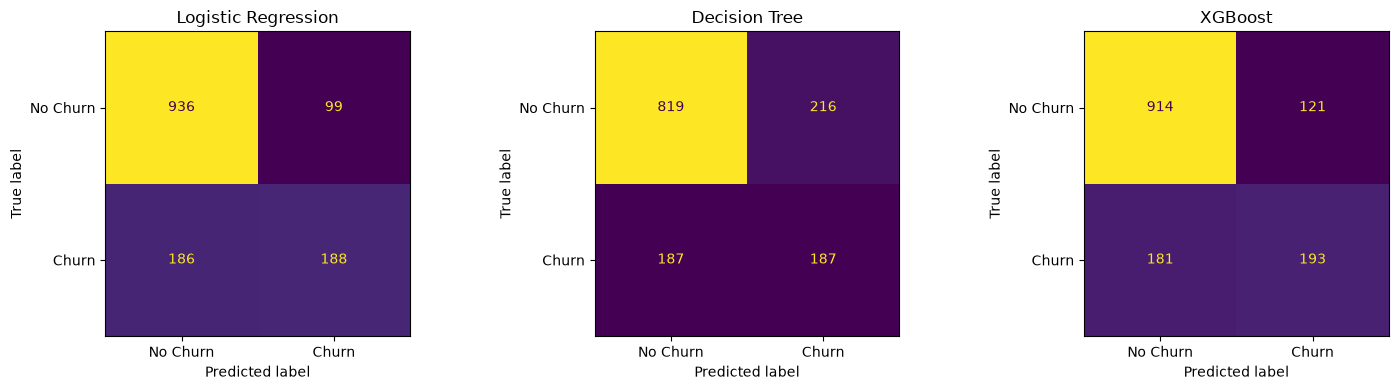

In [15]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))

for ax, (model_name, result) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=["No Churn", "Churn"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

For churn prediction:

- False negatives are churn customers that the model misses.
- False positives are non-churn customers that would receive unnecessary retention actions.

The business impact depends on the relative cost of these two error types.

#### Confusion Matrix

La matriz de confusión muestra cómo se distribuyen las predicciones del modelo comparándolas con la respuesta real.

Cada casilla representa un tipo de predicción:

- **True Negative (TN):** el cliente no hace churn y el modelo predice correctamente que no hará churn.
- **False Positive (FP):** el modelo predice churn, pero el cliente realmente no se iba a ir.
- **False Negative (FN):** el cliente realmente hace churn, pero el modelo no consigue detectarlo.
- **True Positive (TP):** el cliente hace churn y el modelo lo detecta correctamente.

La matriz de confusión permite entender qué tipo de errores comete cada modelo.

Dependiendo del problema de negocio, algunos errores pueden ser más costosos que otros. En este proyecto suele ser especialmente importante reducir los **False Negatives**, ya que representan clientes que se pierden sin haber recibido una oferta de retención.

#### Conclusión

La Logistic Regression proporciona un baseline sólido y fácil de interpretar.

El Decision Tree muestra signos de overfitting y realiza muchas predicciones incorrectas sobre clientes que realmente no harían churn.

XGBoost obtiene el mejor rendimiento general, detectando ligeramente más clientes con churn y reduciendo los False Negatives respecto a Logistic Regression, aunque a costa de una mayor complejidad.

En este notebook no se selecciona todavía un modelo definitivo. El objetivo es establecer un baseline y comparar distintos enfoques antes de realizar la optimización de hiperparámetros en el siguiente notebook.

## 9. Bias-Variance Reflection

In [16]:
bias_variance_df = metrics_df[
    ["model_name", "train_f1", "test_f1", "generalization_gap"]
].sort_values("generalization_gap", ascending=False)

bias_variance_df.round(4)

,model_name,train_f1,test_f1,generalization_gap
1,Decision Tree,0.9963,0.4813,0.5150
2,XGBoost,0.9272,0.5610,0.3661
0,Logistic Regression,0.6036,0.5688,0.0348


A high training score with a much lower test score can indicate overfitting and high variance.

Typical expectations:

- Logistic Regression is often more biased but more stable.
- A single Decision Tree can overfit strongly.
- A Random Forest often reduces variance by averaging many trees.

These are tendencies, not guarantees. The data and model settings still matter.

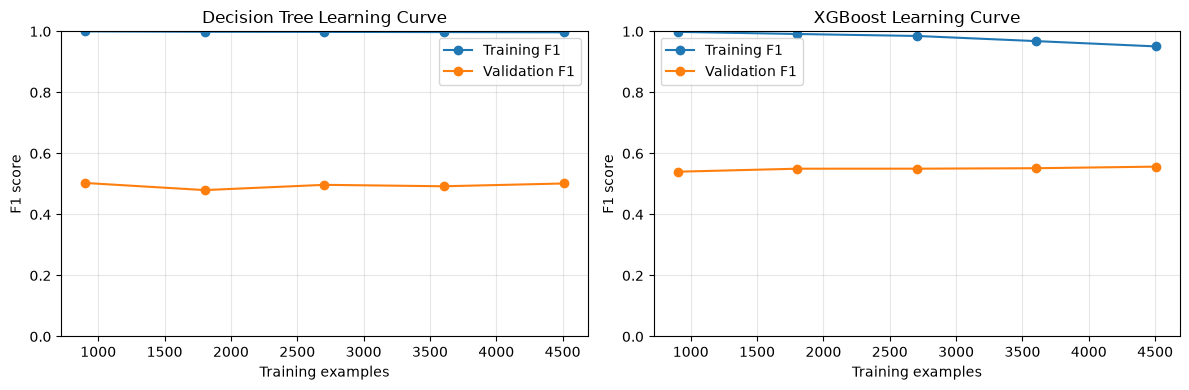

In [17]:
def plot_learning_curve_for_model(model, model_name: str) -> None:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation F1")
    plt.title(model_name)
    plt.xlabel("Training examples")
    plt.ylabel("F1 score")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plot_learning_curve_for_model(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Decision Tree Learning Curve",
)

plt.subplot(1, 2, 2)
plot_learning_curve_for_model(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost Learning Curve",
)

plt.tight_layout()
plt.show()

#### Bias-Variance Reflection

Después de comparar los modelos, también se analiza su capacidad de generalización.

La diferencia entre el rendimiento en entrenamiento (`train_f1`) y en test (`test_f1`) se denomina **generalization gap**.

- Un gap pequeño indica que el modelo generaliza bien a datos nuevos.
- Un gap grande suele indicar **overfitting**, es decir, el modelo aprende demasiado los datos de entrenamiento y rinde peor sobre datos que nunca ha visto.

En este notebook:

- **Logistic Regression** presenta un gap pequeño y un comportamiento estable.
- **Decision Tree** presenta un gap muy grande, indicando un claro overfitting.
- **XGBoost** también presenta cierto overfitting, aunque menor que Decision Tree.

## 10. Save Best Baseline Model

In [18]:
from datetime import datetime


def safe_model_name(name: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in name).strip("_")


best_model_name = metrics_df.sort_values("f1", ascending=False).iloc[0]["model_name"]
best_model = models[best_model_name]
model_class_name = best_model.__class__.__name__
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / f"{timestamp}_{safe_model_name(model_class_name)}_baseline_model.joblib"
joblib.dump(best_model, model_path)

print(f"Best baseline model by F1: {best_model_name}")
print(f"Model class: {model_class_name}")
print(f"Saved model to: {model_path}")

Best baseline model by F1: Logistic Regression
Model class: LogisticRegression
Saved model to: /home/patri/master/2026-06-ads-II-master/models/20260706_140300_LogisticRegression_baseline_model.joblib


#### Save Best Baseline Model

Después de comparar los modelos se selecciona automáticamente el que obtiene el mejor F1.

El modelo entrenado se guarda como un archivo `.joblib`, lo que permite reutilizarlo más adelante sin necesidad de volver a entrenarlo.

También se añade un timestamp al nombre del archivo para mantener diferentes versiones del modelo.

## 11. Experiment Management Log

In team settings, model development should not live only inside individual notebooks. A simple shared sheet can already make work transparent:

- Which experiment was run?
- Who was responsible?
- What hypothesis was tested?
- Which data and features were used?
- What were the key model and business results?
- What is the next decision?

This follows the same principle as the central experimentation log example: use one shared place to document PoC, prototype, and production-oriented experimentation.

For this demo project, the manually maintained experiment log is here:

[reports/experiment_log.xlsx](../reports/experiment_log.xlsx)

It is intentionally treated as a team artifact that is maintained outside the code flow. MLflow will later automate parts of this process, but the underlying discipline is the same.

#### Experiment Management Log

En proyectos reales se registran todos los experimentos realizados (modelo, parámetros, métricas y conclusiones).

Esto facilita reproducir resultados, comparar modelos y entender por qué se eligió una determinada versión.

En este proyecto todavía se utiliza un registro manual. Más adelante MLflow automatizará este proceso.

## 12. Baseline Training Summary

This notebook established an evaluation-first baseline workflow:

- The same evaluation function was used for all models.
- Business KPI calculation is optional and transparent.
- Models were trained from simple to more complex.
- Logistic Regression, Decision Tree, and XGBoost were compared.
- Bias and variance were discussed through train/test gaps and learning curves.

The current results compare a simple linear baseline, a single tree, and XGBoost with default parameters. XGBoost belongs to the broad family of gradient boosting methods, but it is a separate, optimized and regularized implementation with many tuning options.

For the next notebook, we will use XGBoost as the tuning candidate. The plan is:

1. Treat the default XGBoost result as the baseline for this model class.
2. Tune selected hyperparameters in a controlled search.
3. Evaluate every tuned candidate with the same evaluation-first function.
4. Compare whether tuning improves model metrics, probability quality, and the probability-based business KPI.



#### Baseline Training Summary

En este notebook se entrenaron varios modelos baseline utilizando el mismo conjunto de entrenamiento y la misma función de evaluación.

Se compararon métricas de Machine Learning y un KPI de negocio simplificado para seleccionar un primer modelo de referencia.

El siguiente paso será optimizar XGBoost ajustando sus hiperparámetros y comprobar si puede superar al baseline.

Partimos de los datos ya preparados en el Notebook 3. Entrenamos tres modelos distintos (Logistic Regression, Decision Tree y XGBoost) usando el mismo conjunto de entrenamiento. Después los evaluamos con las mismas métricas (Accuracy, Precision, Recall, F1, ROC-AUC) y con un KPI de negocio para poder compararlos de forma justa. Analizamos también el overfitting mediante la diferencia entre train y test y finalmente guardamos el mejor modelo para reutilizarlo más adelante